# Reviewing when climate drivers marked Negative IOD or La Nina

Data from https://www.bom.gov.au/clim_data/IDCK000072/iod_1.txt?1770113793948

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import ocha_stratus as stratus
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import pandas as pd

import re
from src.datasources.era5 import fetch_era5_data

In [3]:
blob_name_iod = "ds-aa-ken-drought/raw/iod.csv"

In [4]:
df = stratus.load_csv_from_blob(blob_name_iod, stage="dev", container_name="projects")

In [5]:
# parse dates
df["Start"] = pd.to_datetime(df["Start"], format="%Y%m%d")
df["End"] = pd.to_datetime(df["End"], format="%Y%m%d")

# flag negative weeks
df["neg_iod"] = df["Value"] <= -0.4

# identify consecutive runs
df["run_id"] = (df["neg_iod"] != df["neg_iod"].shift()).cumsum()

# keep only negative runs
neg_runs = df[df["neg_iod"]].copy()

# count duration (weeks) per run
run_lengths = neg_runs.groupby("run_id").size()

# runs lasting at least 8 weeks
persistent_runs = run_lengths[run_lengths >= 8].index

# extract persistent negative IOD periods
iod_negative_persistent = neg_runs[neg_runs["run_id"].isin(persistent_runs)]

iod_negative_persistent[["Start", "End", "Value"]]

,Start,End,Value
104,2010-07-26,2010-08-01,-0.43
105,2010-08-02,2010-08-08,-0.52
106,2010-08-09,2010-08-15,-0.58
107,2010-08-16,2010-08-22,-0.59
108,2010-08-23,2010-08-29,-1.05
...,...,...,...
899,2025-11-03,2025-11-09,-1.57
900,2025-11-10,2025-11-16,-0.99
901,2025-11-17,2025-11-23,-0.60
902,2025-11-24,2025-11-30,-0.46


In [6]:
summary = (
    iod_negative_persistent.groupby("run_id")
    .agg(
        start_date=("Start", "min"),
        end_date=("End", "max"),
        duration_weeks=("Value", "size"),
        min_dmi=("Value", "min"),
    )
    .reset_index(drop=True)
)

summary

,start_date,end_date,duration_weeks,min_dmi
0,2010-07-26,2010-10-31,14,-1.34
1,2016-06-20,2016-10-23,18,-1.46
2,2020-08-10,2020-10-04,8,-0.96
3,2021-07-12,2021-11-28,20,-0.98
4,2022-06-27,2022-11-13,20,-1.45
5,2025-07-21,2025-12-07,20,-1.94


In [7]:
# most relevant persistent negative IOD events happen between July and November

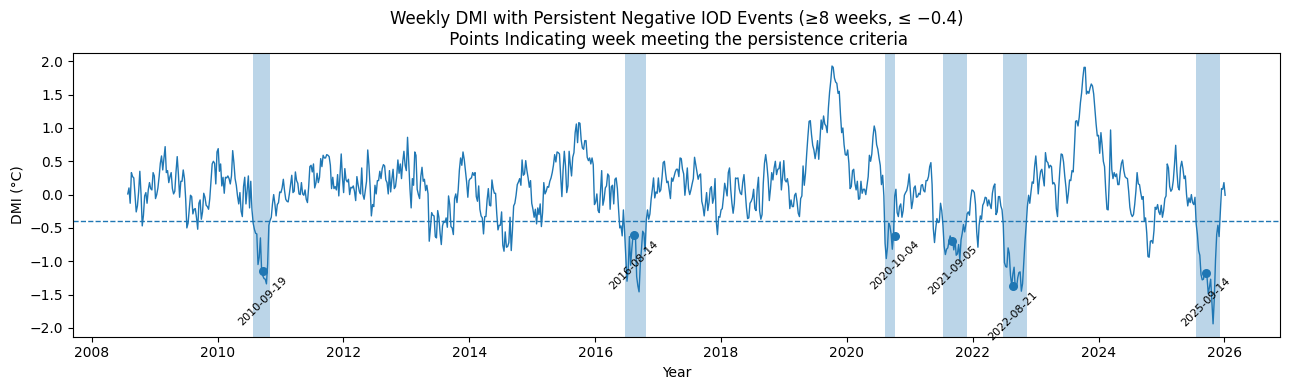

In [8]:
fig, ax = plt.subplots(figsize=(13, 4))

# full time series
ax.plot(df["Start"], df["Value"], linewidth=1)
ax.axhline(-0.4, linestyle="--", linewidth=1)

# shade persistent negative IOD periods
for run_id, g in iod_negative_persistent.groupby("run_id"):
    ax.axvspan(g["Start"].min(), g["End"].max(), alpha=0.3)

# identify the activation week (8th consecutive negative week)
activation_points = iod_negative_persistent.assign(
    week_in_run=iod_negative_persistent.groupby("run_id").cumcount() + 1
).query("week_in_run == 8")

# plot dots at activation point
ax.scatter(
    activation_points["End"],
    activation_points["Value"],
    zorder=4,
    s=30,
)

# label dates
for _, r in activation_points.iterrows():
    ax.text(
        r["End"],
        r["Value"] - 0.05,
        r["End"].strftime("%Y-%m-%d"),
        ha="center",
        va="top",
        fontsize=8,
        rotation=45,
    )

ax.set_xlabel("Year")
ax.set_ylabel("DMI (°C)")
ax.set_title(
    "Weekly DMI with Persistent Negative IOD Events (≥8 weeks, ≤ −0.4)\n Points Indicating week meeting the persistence criteria"
)

plt.tight_layout()
plt.show()